# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

from numpy.random import multivariate_normal, normal
import numpy as np
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux b556f3ab449c 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import helpers.hio as hio
import L09_05_04_non_linear_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [3]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

import filterpy

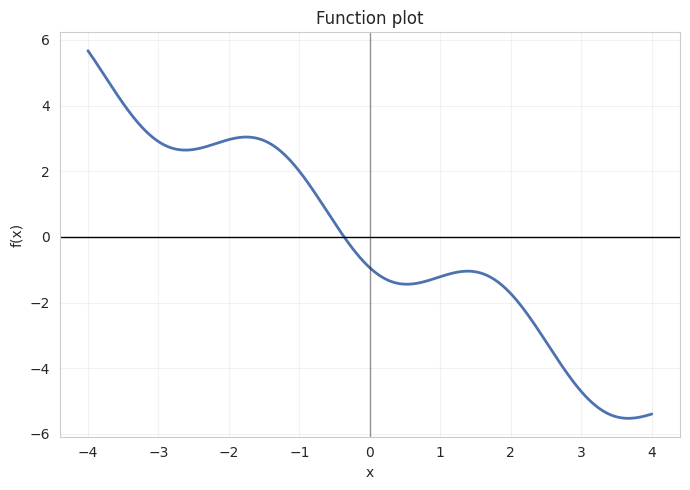

In [4]:
def f(x):
    return (np.cos(4 * (x / 2 + 0.7))) - 1.3 * x


time_ut.plot_function(f)

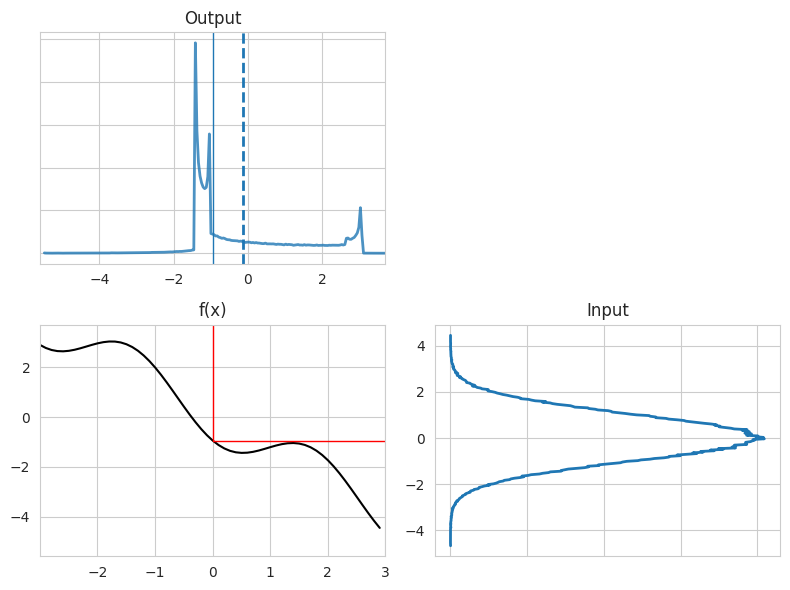

In [5]:
# Create 500,000 samples with mean 0, std 1.
gaussian = (0.0, 1.0)
data = normal(loc=gaussian[0], scale=gaussian[1], size=500000)

time_ut.plot_nonlinear_func(data, f)

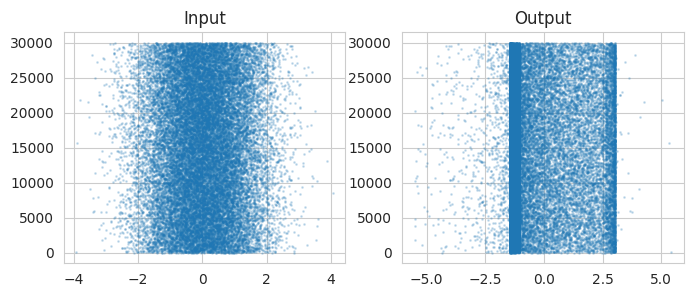

In [6]:
# Plot N points.
N = 30000
plt.subplot(121)
plt.scatter(data[:N], range(N), alpha=0.2, s=1)
plt.title("Input")
plt.subplot(122)
plt.title("Output")
plt.scatter(f(data[:N]), range(N), alpha=0.2, s=1)

In [7]:
def f_nonlinear_xy(x, y):
    return np.array([x + y, 0.1 * x**2 + y * y])

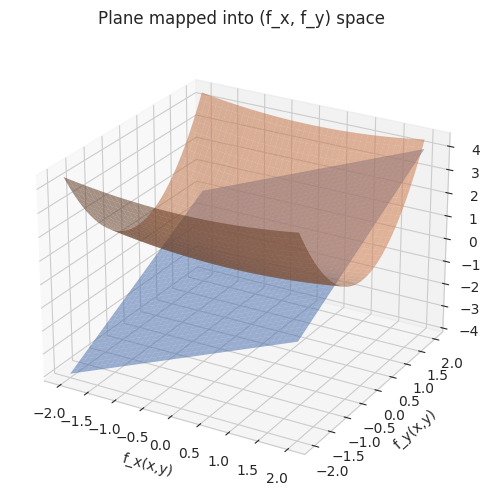

In [8]:
time_ut.plot_nonlinear_xy()

INFO:__main__:f(mean)=[0.06708904 0.00185213]
INFO:__main__:mean(f)=[ 0.06708904 43.25045478]


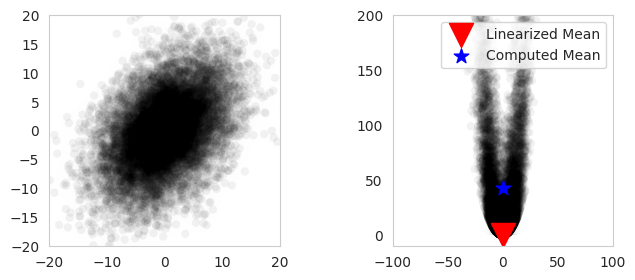

In [9]:
# Create a Gaussian.
N = 10000
mean = (0.0, 0.0)
p = np.array([[32.0, 15.0], [15.0, 40.0]])
xs, ys = multivariate_normal(mean=mean, cov=p, size=N).T

# Compute linearized mean.
mean1 = f_nonlinear_xy(np.mean(xs), np.mean(ys))
_LOG.info("f(mean)=%s", mean1)
mean2 = np.mean(
    [f_nonlinear_xy(xs_tmp, ys_tmp) for xs_tmp, ys_tmp in zip(xs, ys)], axis=0
)
_LOG.info("mean(f)=%s", mean2)
# Plot both.
time_ut.plot_monte_carlo_mean(xs, ys, f_nonlinear_xy, mean1, "Linearized Mean")

### Unscented transform

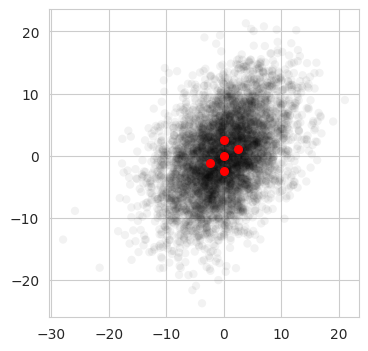

In [10]:
# Create the sigma points for the Gaussian.

from filterpy.kalman import MerweScaledSigmaPoints
import scipy.stats as stats

# Initial mean and covariance.
mean = (0.0, 0.0)
p = np.array([[32.0, 15.0], [15.0, 40.0]])

# Create sigma points and weights from the initial distribution.
points = MerweScaledSigmaPoints(n=2, alpha=0.3, beta=2.0, kappa=0.1)
sigmas = points.sigma_points(mean, p)

# Generate random points.
plt.figure(figsize=[4, 4])
np.random.seed(100)
xs, ys = multivariate_normal(mean=mean, cov=p, size=5000).T
plt.scatter(xs, ys, marker="o", alpha=0.05, color="k", edgecolors="none")
plt.scatter(sigmas[:, 0], sigmas[:, 1], c="r", s=30);

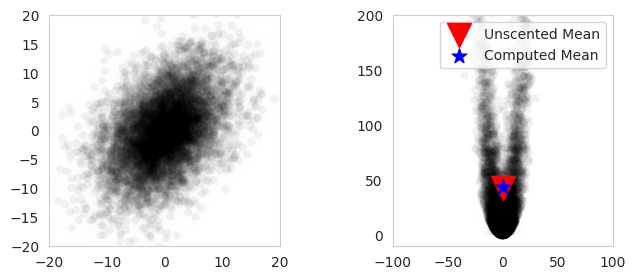

In [11]:
from filterpy.kalman import MerweScaledSigmaPoints, unscented_transform
import scipy.stats as stats

# Transform sigma points through non-linear function.
sigmas_f = np.empty((5, 2))
for i in range(5):
    sigmas_f[i] = f_nonlinear_xy(sigmas[i, 0], sigmas[i, 1])
    
# Use unscented transform to get new mean and covariance.
ukf_mean, ukf_cov = unscented_transform(sigmas_f, points.Wm, points.Wc)

# Generate random points.
np.random.seed(100)
xs, ys = multivariate_normal(mean=mean, cov=p, size=5000).T
time_ut.plot_monte_carlo_mean(xs, ys, f_nonlinear_xy, ukf_mean, "Unscented Mean")

Using only 5 points we were able to compute the mean with great accuracy.

In [12]:
# Compute linearized mean.
mean1 = f_nonlinear_xy(np.mean(xs), np.mean(ys))
_LOG.info("f(mean)=%s", mean1)
#
_LOG.info("mean(f)=%s", ukf_mean)

INFO:__main__:f(mean)=[-0.0965117   0.00646045]
INFO:__main__:mean(f)=[2.00589856e-15 4.32000000e+01]
